In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('academic_performance.csv')

In [3]:
# --- 1. HANDLING INCONSISTENCIES & MISSING VALUES

In [4]:
cols = ['Maths', 'Science', 'English', 'Attendance']
for col in cols:
    print(df[(df[col]<0) | (df[col]>100)])


    Student_ID  Maths  Science  English  Attendance
6            7  150.0     85.0     65.0        88.0
20          21  110.0     85.0     88.0        90.0
   Student_ID  Maths  Science  English  Attendance
7           8   72.0    400.0     78.0        92.0
Empty DataFrame
Columns: [Student_ID, Maths, Science, English, Attendance]
Index: []
    Student_ID  Maths  Science  English  Attendance
17          18   92.0     95.0     98.0       105.0


In [5]:
#CONVERT INCONSISTENT DATA TO NAN
for col in cols:
    df.loc[(df[col] < 0) | (df[col] > 100), col] = np.nan

In [6]:
# Handle all missing values

In [7]:
df.isnull().sum()

Student_ID    0
Maths         4
Science       3
English       2
Attendance    3
dtype: int64

In [8]:
df.mean()

Student_ID    15.500000
Maths         71.269231
Science       72.222222
English       72.678571
Attendance    77.703704
dtype: float64

In [9]:
for col in cols:
    df[col] = df[col].fillna(df[col].mean())

In [10]:
#2. OUTLIER DETECTION & REMOVAL

C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

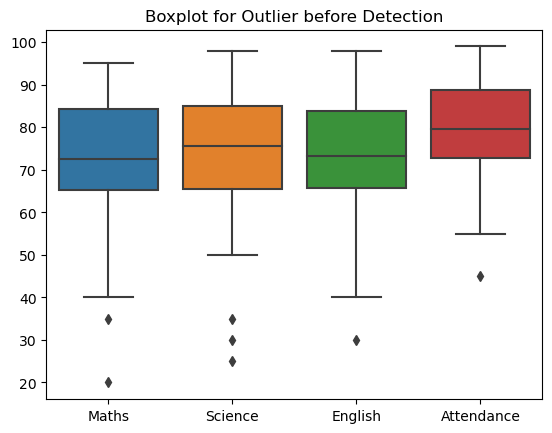

In [22]:
sns.boxplot(data=df[['Maths','Science','English','Attendance']])
plt.title("Boxplot for Outlier before Detection")
plt.show()

In [11]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


In [12]:
print(IQR)
print(lower_bound)
print(upper_bound)

18.25
43.125
116.125


In [24]:
median_val = df[col].median()
df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), col] = median_val

IndexError: invalid index to scalar variable.

C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

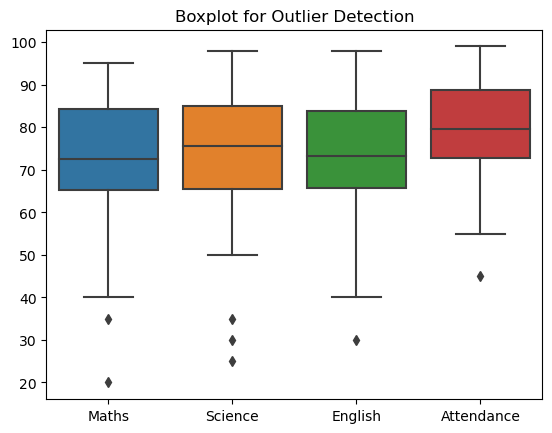

In [14]:
sns.boxplot(data=df[['Maths','Science','English','Attendance']])
plt.title("Boxplot for Outlier Detection")
plt.show()

In [15]:
#3. DATA TRANSFORMATION (Reducing Skewness)

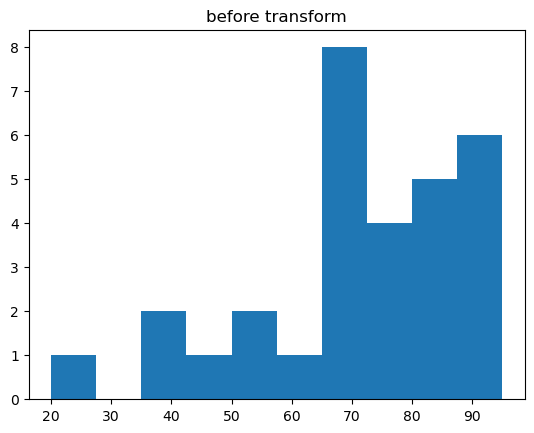

In [16]:
plt.hist(df['Maths'], bins=10)
plt.title("before transform")
plt.show()

In [17]:
df['Maths'].skew()

-1.075896291017944

In [18]:
max = df["Maths"].max()

In [19]:
df["Maths_reflected"] = max + 1 - df["Maths"]
df["Maths_transformed"] = np.sqrt(df["Maths_reflected"])

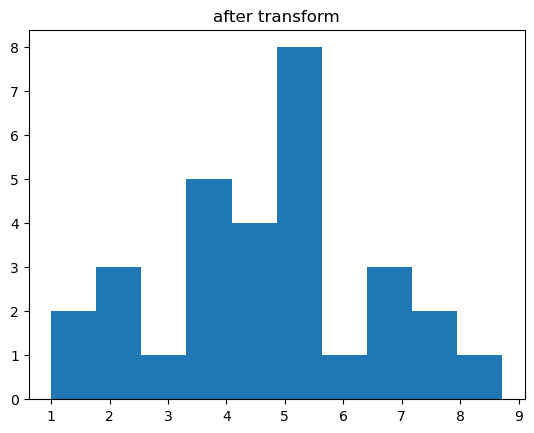

In [20]:
plt.hist(df["Maths_transformed"], bins=10)
plt.title("after transform")
plt.show()

In [21]:
df["Maths_transformed"].skew()

0.050619895169377586